ML Lab-9
AIM: To implement the K-means clustering algorithm and analyze the clustering results using appropriate evaluation techniques   /content/drive/MyDrive/dataset_09/Mall_Customers.csv

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
path = '/content/drive/MyDrive/dataset_09/Mall_Customers.csv'

df=pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
#step 3: Select Relevant Features
# For clustering, we usually select: Annual Income & Spending
# These features are used to segment customers.
X=df.iloc[:,[3,4]].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [13]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
df.isnull().any().any()

np.False_

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

X = pd.get_dummies(X,dtype = int)

X.head()

x =df.iloc[:, [3,4]].values
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [11]:
inertia_values = []

# Select relevant features for clustering
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the features
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(features)

for k in range(1,11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  kmeans.fit(x_scaled)
  inertia_values.append(kmeans.inertia_)
  print(inertia_values)
  plt.figure()

[23.040720326039906]
[23.040720326039906, 14.0859825590406]
[23.040720326039906, 14.0859825590406, 9.05979275116692]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036, 3.585166913062471]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036, 3.585166913062471, 3.2233070168998745]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036, 3.585166913062471, 3.2233070168998745, 2.9095421767924172]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036, 3.585166913062471, 3.2233070168998745, 2.9095421767924172, 2.4699952223283113]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036, 3.585166913062471, 3.2233070168998745, 2.9095421767924172, 2.4699952223283113, 2.2874019043217952]
[23.040720326039906, 14.0859825590406, 9.05979275116692, 6.12185661885036, 3.585166913062471, 3.2233070168998745, 2.9095421767924172, 2.46

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [21]:
from sklearn.preprocessing import StandardScaler
# step 4: feature scaling
# since k-means is distance-based, scaling is important
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


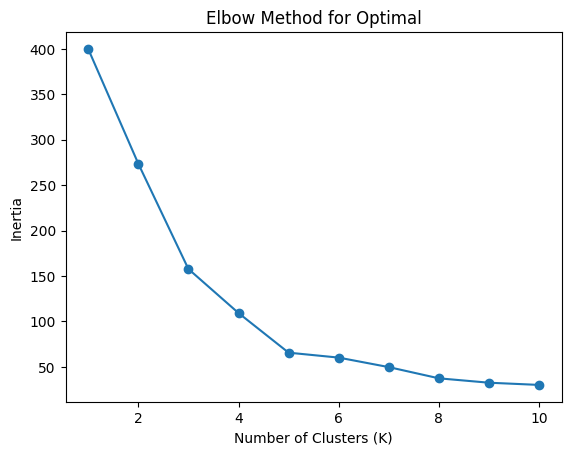

In [22]:
# step 5: Determine optimal cluster(elbow method)
inertia_values = []
for k in range (1,11):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)
  # plotting elbow graph
plt.figure()
plt.plot(range(1,11),inertia_values,marker='o')
plt.title('Elbow Method for Optimal')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [33]:
from sklearn import cluster
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['clusters'] = clusters
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   clusters  
0         4  
1         3  
2         4  
3         3  
4         4  


In [34]:
print("inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

inertia: 37.31912287833882
Silhouette Score: 0.4550112502601921


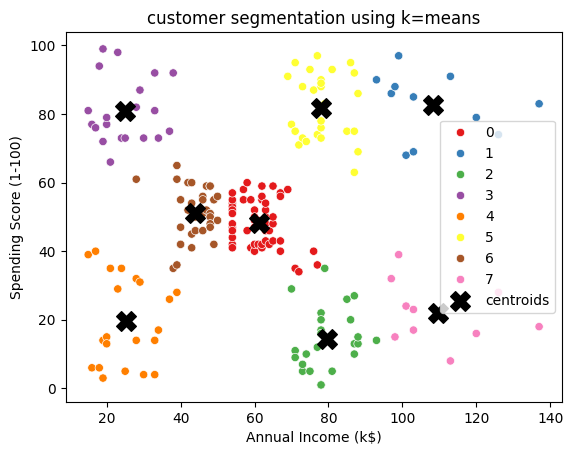

In [35]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='clusters', data=df, palette='Set1')
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, label = 'centroids', color='Black')

plt.title("customer segmentation using k=means")
plt.legend()
plt.show()
